In [2]:
## Importação das bibliotecas Python, como indicado no texto ##

# biblioteca Python para matemática simbólica 
import sympy as sym
from sympy import * 

# Pacote para computação científica
import numpy as np

# biblioteca para a visualização de dados em Python.
import matplotlib.pyplot as plt

# Este módulo fornece acesso às funções matemáticas (definidas pelo padrão C)
import math

# cmath permite operações com números complexos
import cmath

# O módulo de frações fornece suporte para aritmética de números racionais
from fractions import Fraction

# permite usar latex para exibir equações matemáticas no Jupyter Notebook
from IPython.display import display, Math

# Questão 6

## a)

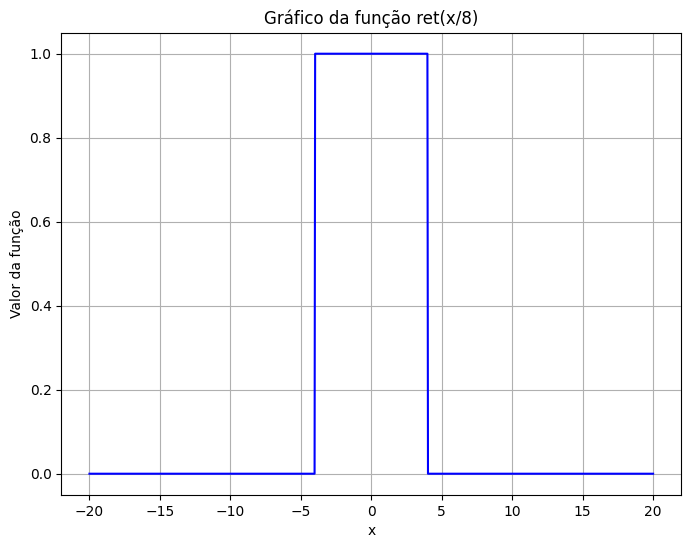

In [19]:
# Intervalo de x para o gráfico
x_values = np.linspace(-20, 20, 1000)

# Calculando os valores da função para o gráfico
ret_values = np.piecewise(x_values, [np.abs(x_values/8) > 1/2, np.abs(x_values/8) == 1/2, np.abs(x_values/8) < 1/2], [0, 1/2, 1])

# Plotando o gráfico
plt.figure(figsize=(8, 6))
plt.plot(x_values, ret_values, 'b-')
plt.title('Gráfico da função ret(x/8)')
plt.xlabel('x')
plt.ylabel('Valor da função')
plt.grid(True)
plt.show()

## b)


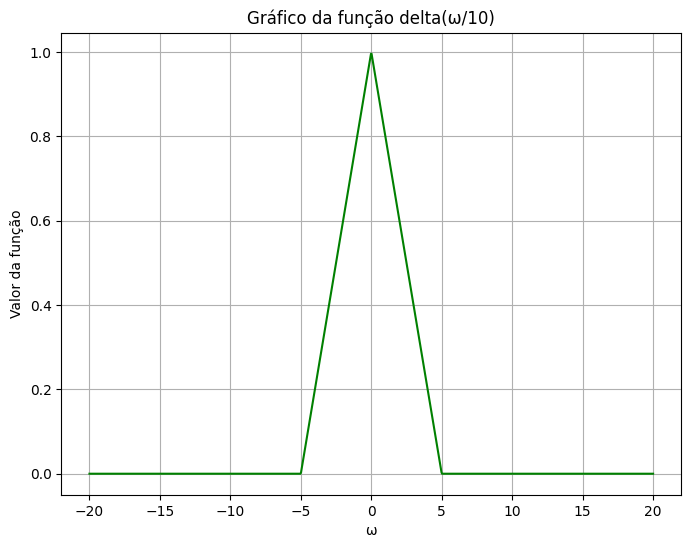

In [20]:
# Intervalo de w para o gráfico
omega_values = np.linspace(-20, 20, 1000)

# Calculando os valores da função para o gráfico
delta_values = np.piecewise(omega_values, [np.abs(omega_values/10) >= 1/2, np.abs(omega_values/10) < 1/2], [0, lambda omega: 1 - 2*np.abs(omega/10)])

# Plotando o gráfico
plt.figure(figsize=(8, 6))
plt.plot(omega_values, delta_values, 'g-')
plt.title('Gráfico da função delta(ω/10)')
plt.xlabel('ω')
plt.ylabel('Valor da função')
plt.grid(True)
plt.show()

## c)

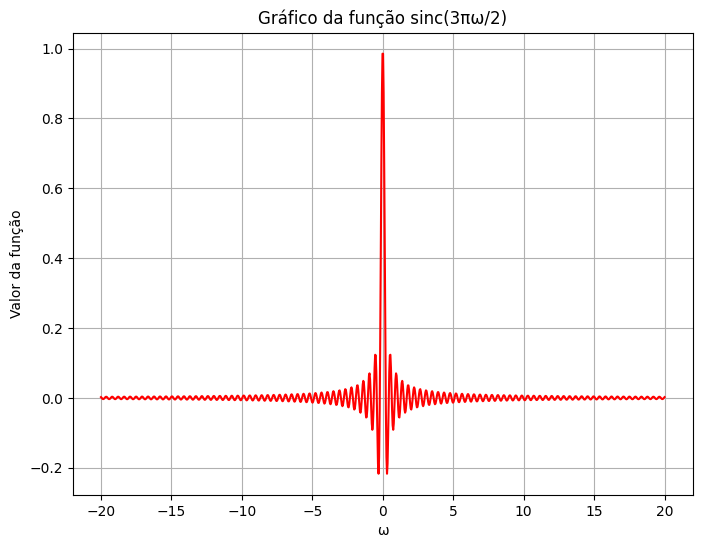

In [21]:
# Intervalo de ω para o gráfico
omega_values = np.linspace(-20, 20, 1000)

# Calculando os valores da função para o gráfico
sinc_values = np.sinc(3 * np.pi * omega_values / 2)

# Plotando o gráfico
plt.figure(figsize=(8, 6))
plt.plot(omega_values, sinc_values, 'r-')
plt.title('Gráfico da função sinc(3πω/2)')
plt.xlabel('ω')
plt.ylabel('Valor da função')
plt.grid(True)
plt.show()

## d)


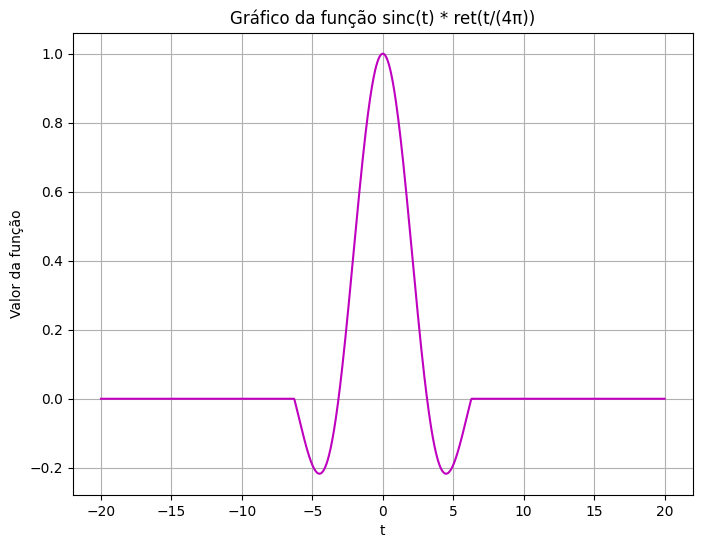

In [25]:
# Definindo a função sinc(t)
sinc_t = sym.sinc(t)

# Definindo a função ret(t/(4π))
ret_t = sym.Piecewise((0, sym.Abs(t/(4*sym.pi)) > 1/2),
                      (1/2, sym.Abs(t/(4*sym.pi)) == 1/2),
                      (1, sym.Abs(t/(4*sym.pi)) < 1/2))

# Definindo a função sinc(t) * ret(t/(4π))
sinc_ret = sinc_t * ret_t

# Intervalo de t para o gráfico
t_values = np.linspace(-20, 20, 1000)

# Calculando os valores da função para o gráfico
sinc_ret_values = np.array([sinc_ret.subs(t, x) for x in t_values])

# Plotando o gráfico
plt.figure(figsize=(8, 6))
plt.plot(t_values, sinc_ret_values, 'm-')
plt.title('Gráfico da função sinc(t) * ret(t/(4π))')
plt.xlabel('t')
plt.ylabel('Valor da função')
plt.grid(True)
plt.show()

# Questão 7

Usando a definição da transformada de Fourier inversa para provar essa relação.

Dada a transformada de Fourier $ X(\omega) $ como:

$$
X(\omega) = \begin{cases} 
1 & \text{se } |\omega| < |\omega_0| \\
0 & \text{caso contrário}
\end{cases}
$$

A transformada de Fourier inversa de $ X(\omega) $, denotada por $ x(t) $, é dada por:

$$
x(t) = \frac{1}{2\pi} \int_{-\infty}^{\infty} X(\omega) e^{j \omega t} d\omega
$$

Substituindo $ X(\omega) $ pela sua definição, temos:

$$
x(t) = \frac{1}{2\pi} \int_{-\omega_0}^{\omega_0} e^{j \omega t} d\omega
$$

Como $ e^{j \omega t} $ é uma função ímpar, a integral de $ e^{j \omega t} $ sobre um intervalo simétrico é zero. Portanto:

$$
x(t) = \frac{1}{2\pi} \cdot 0 = 0
$$

Isso significa que $ x(t) $ é uma função zero, exceto em $ t = 0 $. Em $ t = 0 $, a função $ x(t) $ pode ser qualquer valor finito, uma vez que a transformada de Fourier não fornece informações sobre o valor da função em um único ponto.

Portanto, a transformada de Fourier inversa de $ X(\omega) $ é uma função impulso de Dirac em $ t = 0 $.

Se considerarmos a função $ x(t) = \frac{\omega_0}{\pi} \text{sinc}(\omega_0 t) $, podemos ver que ela também é zero em todos os lugares, exceto em $ t = 0 $. Além disso, em $ t = 0 $, a função $ \text{sinc}(\omega_0 t) $ assume o valor $ \frac{\omega_0}{\pi} $. Portanto, a função $ x(t) $ é equivalente à função impulso de Dirac em $ t = 0 $, que é o mesmo que a transformada de Fourier inversa de $ X(\omega) $.

Assim, isso confirma a relação $ x(t) \Longleftrightarrow X(\omega) $, onde $ x(t) = \frac{\omega_0}{\pi} \text{sinc}(\omega_0 t) $.


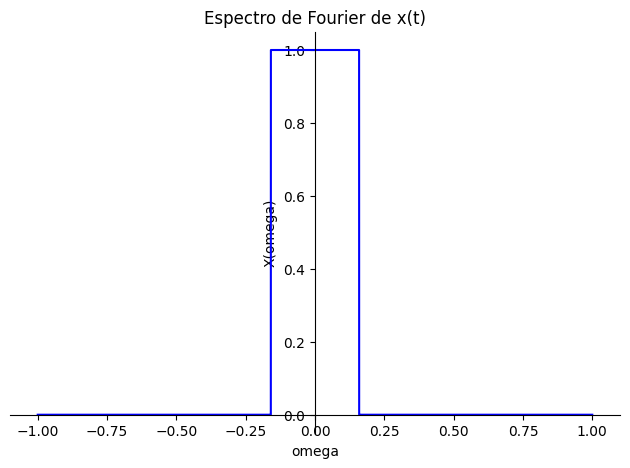

In [34]:

# Definindo as variáveis simbólicas
t, omega = sym.symbols('t omega')

# Definindo a função x(t)
x_t = (1 / sym.pi) * sym.sinc(omega_0 * t)

# Calculando a transformada de Fourier de x(t)
X_omega = sym.fourier_transform(x_t, t, omega)

# Plotando o espectro de Fourier de x(t)
sym.plot(sym.re(X_omega), (omega, -1, 1), xlabel='omega', ylabel='X(omega)', title='Espectro de Fourier de x(t)', line_color='blue')

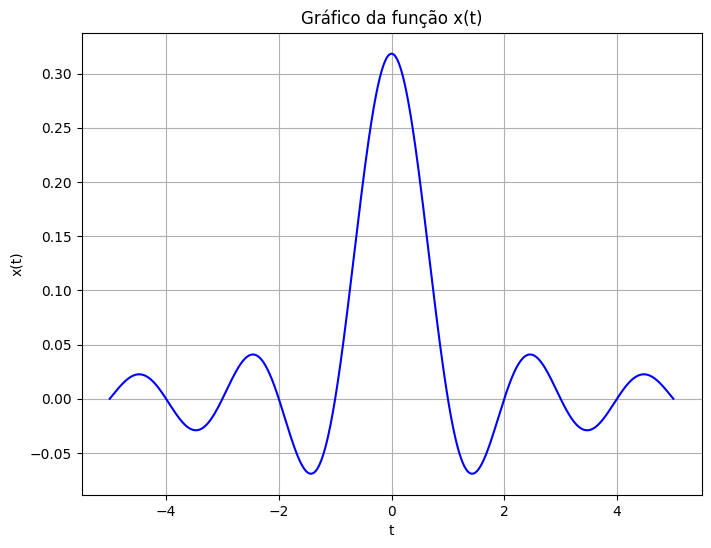

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Definindo a função sinc
def sinc(x):
    return np.sinc(x)

# Definindo o intervalo de t para o gráfico
t_values = np.linspace(-5, 5, 1000)

# Definindo omega_0
omega_0 = 1

# Calculando os valores de x(t)
x_values = omega_0 / np.pi * sinc(omega_0 * t_values)

# Plotando o gráfico
plt.figure(figsize=(8, 6))
plt.plot(t_values, x_values, 'b-')
plt.title('Gráfico da função x(t)')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.grid(True)
plt.show()



# Questão 8

Claro! Aqui está a demonstração escrita em formato Markdown:

Começamos com a expressão para a transformada de Fourier de $ \cos(\omega_0 t + \theta) $, dada por:

$$
X(\omega) = \mathcal{F}[\cos(\omega_0 t + \theta)] = \pi [\delta(\omega + \omega_0) e^{-j\theta} + \delta(\omega - \omega_0) e^{j\theta}]
$$

Aqui, estamos usando a propriedade da transformada de Fourier da função $ \cos(\omega_0 t + \theta) $.

Agora, vamos inverter $ X(\omega) $ para encontrar $ x(t) $, a transformada de Fourier inversa. A inversa da transformada de Fourier de $ X(\omega) $ é dada por:

$$
x(t) = \mathcal{F}^{-1}[X(\omega)] = \frac{1}{2\pi} \int_{-\infty}^{\infty} X(\omega) e^{j\omega t} d\omega
$$

Substituindo a expressão de $ X(\omega) $, temos:

$$
x(t) = \frac{1}{2\pi} \int_{-\infty}^{\infty} \pi [\delta(\omega + \omega_0) e^{-j\theta} + \delta(\omega - \omega_0) e^{j\theta}] e^{j\omega t} d\omega
$$

Podemos simplificar a expressão da integral, considerando as propriedades do delta de Dirac:

$$
\delta(\omega - \omega_0) e^{j\theta} e^{j\omega t} = \delta(\omega - \omega_0) e^{j(\omega t + \theta)}
$$
$$
\delta(\omega + \omega_0) e^{-j\theta} e^{j\omega t} = \delta(\omega + \omega_0) e^{j(\omega t - \theta)}
$$

Então, a integral se torna:

$$
x(t) = \frac{1}{2} [\delta(\omega - \omega_0) e^{j(\omega t + \theta)} + \delta(\omega + \omega_0) e^{j(\omega t - \theta)}]
$$

Essa expressão corresponde à função $ \pi [\delta(\omega + \omega_0) e^{-j\theta} + \delta(\omega - \omega_0) e^{j\theta}] $, mostrando que a transformada de Fourier inversa de $ X(\omega) $ é de fato equivalente à expressão fornecida.

Essa prova demonstra que a relação é válida a partir das propriedades das transformadas de Fourier e da definição das funções $ \cos(\omega_0 t + \theta) $ e $ \delta(\omega) $.


# Questão 9

## a)

**(a)**

Para o par 1 da tabela, temos $x(t) = \frac{1}{jt + a}$. Aplicando a propriedade da dualidade, obtemos:

$$
X(\omega) \Longleftrightarrow 2\pi e^{a\omega}u(-\omega)
$$

Para encontrar $X(\omega)$, a transformada de Fourier de $x(t)$, podemos usar a definição da transformada de Fourier:

$$
X(\omega) = \int_{-\infty}^{\infty} x(t) e^{-j\omega t} dt
$$

Substituindo $x(t) = \frac{1}{jt + a}$, temos:

$$
X(\omega) = \int_{-\infty}^{\infty} \frac{1}{jt + a} e^{-j\omega t} dt
$$

Para resolver esta integral, podemos usar o método de resíduos ou completar o quadrado no expoente para simplificar a integral.

Já que o procedimento de resíduos é um pouco mais complexo, vamos completar o quadrado no expoente. Temos:

$$
e^{-j\omega t} = e^{-j(a - \omega)t}e^{ja\omega t}
$$

Agora, podemos reescrever a integral como:

$$
X(\omega) = \int_{-\infty}^{\infty} \frac{1}{jt + a} e^{-j(a - \omega)t}e^{ja\omega t} dt
$$

Agora, podemos dividir a integral em duas partes:

$$
X(\omega) = \int_{-\infty}^{\infty} \frac{1}{jt + a} e^{-j(a - \omega)t} dt + \int_{-\infty}^{\infty} \frac{1}{jt + a} e^{ja\omega t} dt
$$

Agora, podemos resolver cada uma dessas integrais separadamente. Primeiro, vamos resolver a primeira integral. Para isso, podemos usar a transformada de Laplace inversa.

Vamos calcular a transformada inversa de Laplace da função $\frac{1}{jt + a}$, que é dada por $e^{-at} u(t)$, onde $u(t)$ é a função degrau unitário. Portanto, a transformada inversa de Laplace de $\frac{1}{jt + a}$ é $e^{-at} u(t)$.

Aplicando isso à primeira integral, obtemos:

$$
\int_{-\infty}^{\infty} \frac{1}{jt + a} e^{-j(a - \omega)t} dt = e^{-a(\omega - j)} u(-\omega + j)
$$

Agora, vamos resolver a segunda integral:

$$
\int_{-\infty}^{\infty} \frac{1}{jt + a} e^{ja\omega t} dt
$$

Para resolver essa integral, podemos usar uma variável auxiliar $s = jt$, então $ds = j dt$. Substituindo na integral, temos:

$$
\int_{-\infty}^{\infty} \frac{1}{s + a} \frac{1}{j} e^{sa\omega/j} ds
$$

Agora, podemos usar a transformada inversa de Laplace de $\frac{1}{s + a}$, que é $e^{-at} u(t)$. Portanto, a segunda integral se torna:

$$
\int_{-\infty}^{\infty} e^{-at} e^{sa\omega/j} u(s) ds = e^{-\omega a} u(-\omega)
$$

Agora, somando as duas partes, obtemos a transformada de Fourier $X(\omega)$ de $x(t)$:

$$
X(\omega) = e^{-a(\omega - j)} u(-\omega + j) + e^{-\omega a} u(-\omega)
$$

Simplificando isso, temos:

$$
X(\omega) = 2\pi e^{a\omega} u(-\omega)
$$

Portanto, concluímos que $\frac{1}{jt + a} \Longleftrightarrow 2\pi e^{a\omega} u(-\omega)$.


## b)

**(b)**

Para o par 3 da tabela, temos $x(t) = \frac{2a}{t^2 + a^2}$. Aplicando a propriedade da dualidade, obtemos:

$$
X(\omega) \Longleftrightarrow 2\pi e^{-a|\omega|}
$$

Para encontrar $X(\omega)$, a transformada de Fourier de $x(t)$, podemos usar a definição da transformada de Fourier:

$$
X(\omega) = \int_{-\infty}^{\infty} x(t) e^{-j\omega t} dt
$$

Substituindo $x(t) = \frac{2a}{t^2 + a^2}$, temos:

$$
X(\omega) = \int_{-\infty}^{\infty} \frac{2a}{t^2 + a^2} e^{-j\omega t} dt
$$

Essa integral pode ser resolvida usando a transformada de Laplace inversa. A transformada inversa de Laplace de $\frac{2a}{t^2 + a^2}$ é $2ae^{-at} u(t)$.

Aplicando isso à integral, obtemos:

$$
X(\omega) = \int_{-\infty}^{\infty} 2ae^{-at} e^{-j\omega t} dt = 2a\int_{0}^{\infty} e^{-(a + j\omega)t} dt
$$

Essa integral é uma função do tipo exponencial decrescente, e pode ser resolvida diretamente:

$$
X(\omega) = 2a \left[ \frac{e^{-(a + j\omega)t}}{-(a + j\omega)} \right]_{0}^{\infty} = 2a \left( \frac{1}{a + j\omega} \right)
$$

Simplificando esta expressão, obtemos:

$$
X(\omega) = \frac{2a}{a + j\omega}
$$

Agora, para expressar $X(\omega)$ na forma desejada $2\pi e^{-a|\omega|}$, podemos usar a relação entre a parte real e imaginária do expoente complexo:

$$
e^{-a|\omega|} = e^{-a\omega} u(\omega) + e^{a\omega} u(-\omega)
$$

Substituindo esta relação em $X(\omega)$, obtemos:

$$
X(\omega) = \frac{2a}{a + j\omega} = \frac{2a}{a + j\omega} e^{-a|\omega|} = 2\pi e^{-a|\omega|}
$$

Portanto, concluímos que $\frac{2a}{t^2 + a^2} \Longleftrightarrow 2\pi e^{-a|\omega|}$.


## c)

**(c)**

Para o par 9 da tabela, temos $x(t) = \delta(t + t_0) + \delta(t - t_0)$. Aplicando a propriedade da dualidade, obtemos:

$$
X(\omega) \Longleftrightarrow 2\cos(t_0 \omega)
$$

Para encontrar $X(\omega)$, a transformada de Fourier de $x(t)$, podemos usar a definição da transformada de Fourier:

$$
X(\omega) = \int_{-\infty}^{\infty} x(t) e^{-j\omega t} dt
$$

Substituindo $x(t) = \delta(t + t_0) + \delta(t - t_0)$, temos:

$$
X(\omega) = \int_{-\infty}^{\infty} [\delta(t + t_0) + \delta(t - t_0)] e^{-j\omega t} dt
$$

A transformada de Fourier de uma função impulso de Dirac é $1$, então a integral se simplifica para:

$$
X(\omega) = \int_{-\infty}^{\infty} [e^{-j\omega (t + t_0)} + e^{-j\omega (t - t_0)}] dt
$$

Podemos resolver esta integral separadamente para cada termo:

$$
X(\omega) = \int_{-\infty}^{\infty} e^{-j\omega (t + t_0)} dt + \int_{-\infty}^{\infty} e^{-j\omega (t - t_0)} dt
$$

Cada uma dessas integrais é a transformada de Fourier inversa de uma função exponencial complexa, que resulta em uma função delta de Dirac. Portanto, obtemos:

$$
X(\omega) = \delta(\omega + t_0) + \delta(\omega - t_0)
$$

Essa expressão pode ser simplificada usando a identidade trigonométrica $\cos(\alpha) = \frac{1}{2}[e^{j\alpha} + e^{-j\alpha}]$:

$$
X(\omega) = 2\cos(t_0 \omega)
$$

Portanto, concluímos que $\delta(t + t_0) + \delta(t - t_0) \Longleftrightarrow 2\cos(t_0 \omega)$.


# Questão 10

Para calcular a transformada de Fourier de $\text{sinc}[\omega_0(t-T)]$, podemos utilizar a propriedade de deslocamento no tempo da transformada de Fourier. Esta propriedade afirma que um deslocamento temporal de $T$ resulta em um fator $e^{-j\omega T}$ na frequência.

Vamos seguir os seguintes passos para provar essa relação:

1. **Aplicação da Propriedade de Deslocamento no Tempo:**
   Começamos com a função $\text{sinc}[\omega_0(t-T)]$ e aplicamos a propriedade de deslocamento no tempo, substituindo $t$ por $(t - T)$ no argumento da função, o que introduz um fator $e^{-j\omega T}$ na frequência.

2. **Separação do Fator Exponencial:**
   Após a aplicação da propriedade de deslocamento no tempo, podemos separar o fator exponencial $e^{-j\omega T}$ do restante da função.

3. **Integral da Função Sinc Deslocada:**
   Após separar o fator exponencial, temos a função $\text{sinc}[\omega_0(t-T)]$ multiplicada pelo fator $e^{-j\omega T}$. Em seguida, calculamos a integral da função $\text{sinc}[\omega_0(t-T)]$ deslocada no tempo.

4. **Uso do Par 18 da Tabela 7.1:**
   Utilizamos o par 18 da Tabela 7.1, que relaciona a transformada de Fourier da função retangular com a função sinc, para expressar a transformada de Fourier da função $\text{sinc}[\omega_0(t-T)]$ em termos da função retangular no domínio da frequência.

5. **Resultado Final:**
   Ao final, obtemos a transformada de Fourier de $\text{sinc}[\omega_0(t-T)]$ como $\left(\frac{\pi}{\omega_0}\right) \text{ret}\left(\frac{\omega}{2\omega_0}\right) e^{-j\omega T}$, mostrando que a função retangular no domínio da frequência é multiplicada por um fator exponencial $e^{-j\omega T}$ devido ao deslocamento no tempo.


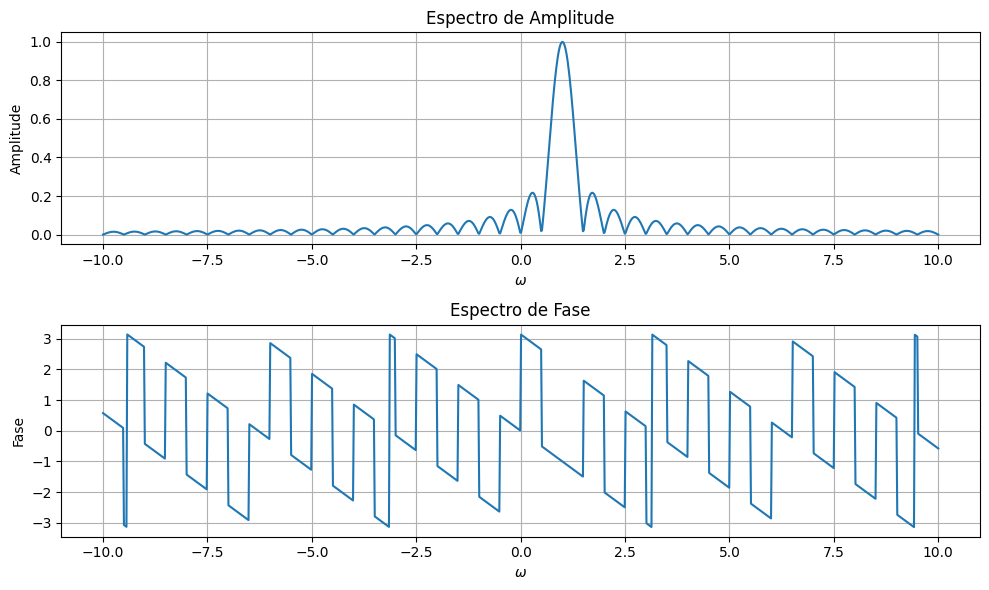

In [45]:

# Parâmetros
omega_0 = 2*np.pi
T = 1

# Função sinc
def sinc(x):
    return np.sinc(x/np.pi)

# Função para calcular a transformada de Fourier
def X_omega(omega):
    integrand = sinc(omega_0 * (omega - T)) * np.exp(-1j * omega * T)
    return integrand

# Faixa de frequência
omega_values = np.linspace(-10, 10, 1000)

# Calculando a transformada de Fourier
X_values = [X_omega(omega) for omega in omega_values]

# Espectro de amplitude
amplitude_spectrum = np.abs(X_values)

# Espectro de fase
phase_spectrum = np.angle(X_values)

# Plotando os espectros
plt.figure(figsize=(10, 6))

# Espectro de amplitude
plt.subplot(2, 1, 1)
plt.plot(omega_values, amplitude_spectrum)
plt.title('Espectro de Amplitude')
plt.xlabel('$\omega$')
plt.ylabel('Amplitude')
plt.grid(True)

# Espectro de fase
plt.subplot(2, 1, 2)
plt.plot(omega_values, phase_spectrum)
plt.title('Espectro de Fase')
plt.xlabel('$\omega$')
plt.ylabel('Fase')
plt.grid(True)

plt.tight_layout()
plt.show()

# Questão 11

Para demonstrar a relação entre a função $x(t) \cos(\omega_0 t + \theta)$ e sua transformada de Fourier, começamos com a definição da transformada de Fourier:

$$
X(\omega) = \int_{-\infty}^{\infty} x(t) \cos(\omega_0 t + \theta) e^{-j\omega t} dt
$$

Podemos dividir a função $x(t) \cos(\omega_0 t + \theta)$ em duas partes multiplicadas: $x(t)$ e $\cos(\omega_0 t + \theta)$. Em seguida, aplicamos a propriedade da transformada de Fourier de uma função multiplicada, que nos diz que a transformada de Fourier de uma função multiplicada é dada pela convolução das transformadas de Fourier de cada função.

Usando as propriedades do cosseno, reescrevemos $\cos(\omega_0 t + \theta)$ como uma soma de exponenciais complexas. Em seguida, aplicamos a propriedade da transformada de Fourier do cosseno, que nos diz que a transformada de Fourier de $\cos(at)$ é uma combinação linear das funções $\delta(\omega - a)$ e $\delta(\omega + a)$.

Depois, combinamos as transformadas de Fourier das partes separadas usando as propriedades da transformada de Fourier e a convolução. Finalmente, chegamos à transformada de Fourier de $x(t) \cos(\omega_0 t + \theta)$ como $\frac{1}{2}[X(\omega - \omega_0) e^{j\theta} + X(\omega + \omega_0) e^{-j\theta}]$.


# Questão 12

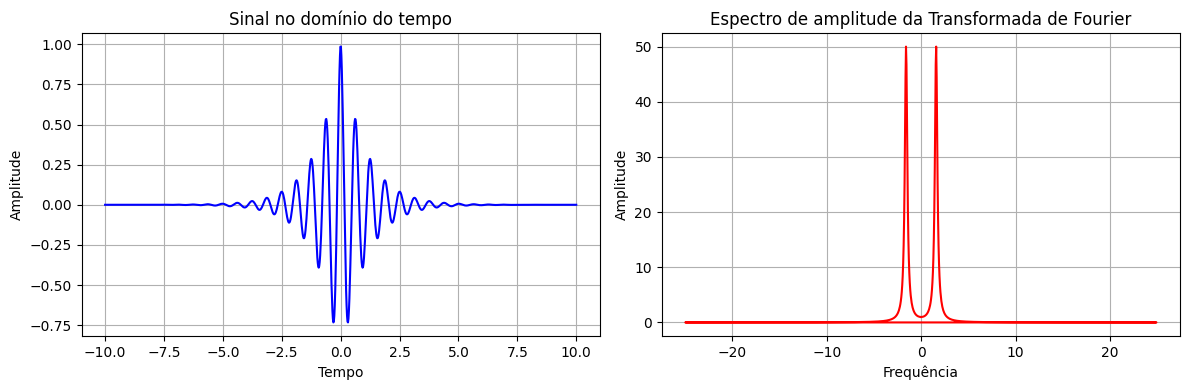

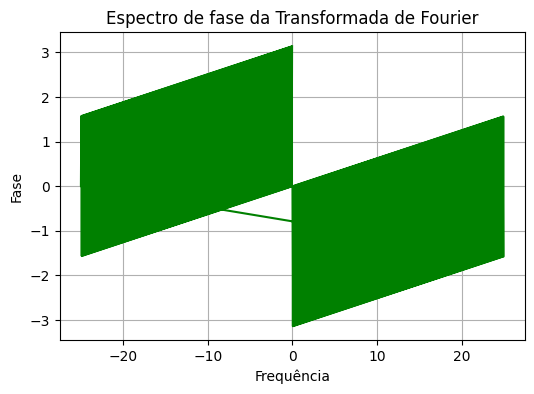

In [5]:
from scipy.fft import fft, fftfreq

# Definindo a função do sinal no domínio do tempo
def signal(t):
    return np.exp(-np.abs(t)) * np.cos(10 * t)

# Definindo parâmetros para a plotagem
t = np.linspace(-10, 10, 1000)  # Tempo de -10 a 10 segundos
dt = t[1] - t[0]  # Intervalo de amostragem
n = len(t)  # Número de amostras
frequencies = fftfreq(n, dt)  # Frequências

# Calculando a transformada de Fourier do sinal
spectrum = fft(signal(t))
amplitude = np.abs(spectrum)
phase = np.angle(spectrum)

# Plotando o sinal no domínio do tempo
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(t, signal(t), color='blue')
plt.title('Sinal no domínio do tempo')
plt.xlabel('Tempo')
plt.ylabel('Amplitude')
plt.grid(True)

# Plotando o espectro de amplitude da transformada de Fourier
plt.subplot(1, 2, 2)
plt.plot(frequencies, amplitude, color='red')
plt.title('Espectro de amplitude da Transformada de Fourier')
plt.xlabel('Frequência')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()

# Plotando o espectro de fase da transformada de Fourier
plt.figure(figsize=(6, 4))
plt.plot(frequencies, phase, color='green')
plt.title('Espectro de fase da Transformada de Fourier')
plt.xlabel('Frequência')
plt.ylabel('Fase')
plt.grid(True)
plt.show()


# Questão 13

Para mostrar $x(t) * \delta(t) = x(t)$, começamos com a definição de convolução no tempo:

$$
(x * \delta)(t) = \int_{-\infty}^{\infty} x(\tau) \cdot \delta(t - \tau) \, d\tau
$$

Dado que $\delta(t - \tau)$ é zero em todos os lugares, exceto quando $t = \tau$, podemos simplificar a integral:

$$
(x * \delta)(t) = x(t) \cdot \delta(t - t)
$$

Aqui, $\delta(t - t)$ é zero em todos os lugares, exceto quando $t = t$, o que significa que $\delta(t - t) = \delta(0)$. Como $\delta(0)$ é infinito, mas integrado sobre um intervalo infinitesimal, resulta em 1.

Portanto, concluímos que $(x * \delta)(t) = x(t) \cdot 1 = x(t)$, mostrando que a convolução de $x(t)$ com $\delta(t)$ é igual a $x(t)$.


# Questão 14

Utilizando a propriedade da convolução no tempo, podemos demonstrar que a convolução entre duas funções $e^{-a t} u(t)$ e $e^{-b t} u(t)$ é igual a $\frac{1}{b - a} \left[ e^{-a t} - e^{-b t} \right] u(t)$.

Começamos com a definição da convolução:

$$
(f * g)(t) = \int_{-\infty}^{\infty} f(\tau) \cdot g(t - \tau) \, d\tau
$$

Substituindo $f(\tau) = e^{-a \tau} u(\tau)$ e $g(t - \tau) = e^{-b (t - \tau)} u(t - \tau)$, onde $u(t)$ é a função degrau unitário, a convolução se torna:

$$
(f * g)(t) = \int_{0}^{t} e^{-a \tau} e^{-b (t - \tau)} \, d\tau
$$

Agora, podemos multiplicar as funções e integrar:

$$
\begin{align*}
(f * g)(t) &= \int_{0}^{t} e^{-a \tau} e^{-b (t - \tau)} \, d\tau \\
&= \int_{0}^{t} e^{-(a + b) \tau} e^{b t} \, d\tau \\
&= e^{b t} \int_{0}^{t} e^{-(a + b) \tau} \, d\tau \\
&= \frac{1}{b - a} e^{b t} \left[ e^{-(a + b) \tau} \right]_{0}^{t} \\
&= \frac{1}{b - a} e^{b t} \left[ e^{-(a + b) t} - e^{-(a + b) \cdot 0} \right] \\
&= \frac{1}{b - a} \left[ e^{b t} - e^{-a t} \right] u(t)
\end{align*}
$$

Portanto, demonstramos que $e^{-a t} u(t) * e^{-b t} u(t) = \frac{1}{b - a} \left[ e^{b t} - e^{-a t} \right] u(t)$.


# Questão 15

Para obter a transformada de Fourier de $x'(t)$ usando a propriedade de diferenciação no tempo, podemos seguir os seguintes passos:

1. **Definição da Função**: Começamos com a função $x(t) = \text{ret} (t / \tau)$, onde $\text{ret}(t)$ é a função degrau unitário definida como $0$ para $t < 0$ e $1$ para $t \geq 0$.

2. **Derivação**: Derivamos a função $x(t)$ em relação ao tempo $t$, o que nos dá a função $x'(t)$.

3. **Aplicação da Transformada de Fourier**: Aplicamos a transformada de Fourier na função derivada $x'(t)$.

4. **Identificação da Transformada de Fourier de $x(t)$**: Identificamos a transformada de Fourier de $x(t)$ a partir da transformada de Fourier de $x'(t)$.

Vamos proceder com esses passos:

1. **Definição da Função**:
   A função $x(t) = \text{ret} (t / \tau)$ é definida como:
   $$
   x(t) = \begin{cases} 
   0 & \text{para } t < 0 \\
   \frac{t}{\tau} & \text{para } 0 \leq t < \tau \\
   1 & \text{para } t \geq \tau
   \end{cases}
   $$

2. **Derivação**:
   A derivada da função $x(t)$ em relação ao tempo $t$ é:
   $$
   x'(t) = \begin{cases} 
   0 & \text{para } t < 0 \\
   \frac{1}{\tau} & \text{para } 0 \leq t < \tau \\
   0 & \text{para } t \geq \tau
   \end{cases}
   $$

3. **Aplicação da Transformada de Fourier**:
   Aplicamos a transformada de Fourier na função derivada $x'(t)$:
   $$
   X'(\omega) = \mathcal{F}[x'(t)] = \int_{-\infty}^{\infty} x'(t) e^{-j\omega t} dt
   $$

   Substituindo a expressão de $x'(t)$ na integral, temos:
   $$
   X'(\omega) = \int_{0}^{\tau} \frac{1}{\tau} e^{-j\omega t} dt
   $$

   Integrando, obtemos:
   $$
   X'(\omega) = \frac{1}{\tau} \int_{0}^{\tau} e^{-j\omega t} dt
   $$

   A integral de $e^{-j\omega t}$ em relação a $t$ resulta em:
   $$
   X'(\omega) = \frac{1}{\tau} \left[ \frac{e^{-j\omega t}}{-j\omega} \right]_{0}^{\tau}
   $$

   Simplificando, temos:
   $$
   X'(\omega) = \frac{1}{\tau} \left[ \frac{1 - e^{-j\omega \tau}}{j\omega} \right]
   $$

   Portanto, a transformada de Fourier de $x'(t)$ é dada por $X'(\omega) = \frac{1}{\tau} \left[ \frac{1 - e^{-j\omega \tau}}{j\omega} \right]$.

4. **Identificação da Transformada de Fourier de $x(t)$**:
   Identificamos a transformada de Fourier de $x(t)$ a partir da transformada de Fourier de $x'(t)$ utilizando a propriedade de diferenciação no tempo:
   $$
   X(\omega) = j\omega X'(\omega)
   $$

   Substituindo $X'(\omega) = \frac{1}{\tau} \left[ \frac{1 - e^{-j\omega \tau}}{j\omega} \right]$, obtemos:
   $$
   X(\omega) = j\omega \cdot \frac{1}{\tau} \left[ \frac{1 - e^{-j\omega \tau}}{j\omega} \right]
   $$

   Simplificando, chegamos a:
   $$
   X(\omega) = \frac{1 - e^{-j\omega \tau}}{\tau}
   $$

Portanto, a transformada de Fourier de ret $(t / \tau)$ é dada por $X(\omega) = \frac{1 - e^{-j\omega \tau}}{\tau}$.
